In [ ]:
!pip install -q pycbc

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

from pycbc.waveform import get_td_waveform
from scipy.signal import resample

os.makedirs("figures", exist_ok=True)
os.makedirs("data", exist_ok=True)

In [ ]:
# Sampling setup
sample_rate = 4096
delta_t = 1.0 / sample_rate

# Approximate GW150914-like binary black-hole system
mass1 = 36
mass2 = 29
distance = 410  # Mpc, approximate GW150914 luminosity distance

hp, hc = get_td_waveform(
    approximant="IMRPhenomD",
    mass1=mass1,
    mass2=mass2,
    spin1z=0,
    spin2z=0,
    distance=distance,
    delta_t=delta_t,
    f_lower=20
)

print(hp)
print("Number of samples:", len(hp))

[1.14814943e-26 1.13132494e-26 1.11490955e-26 ... 1.19246901e-26
 1.17957530e-26 1.16461509e-26]
Number of samples: 65536


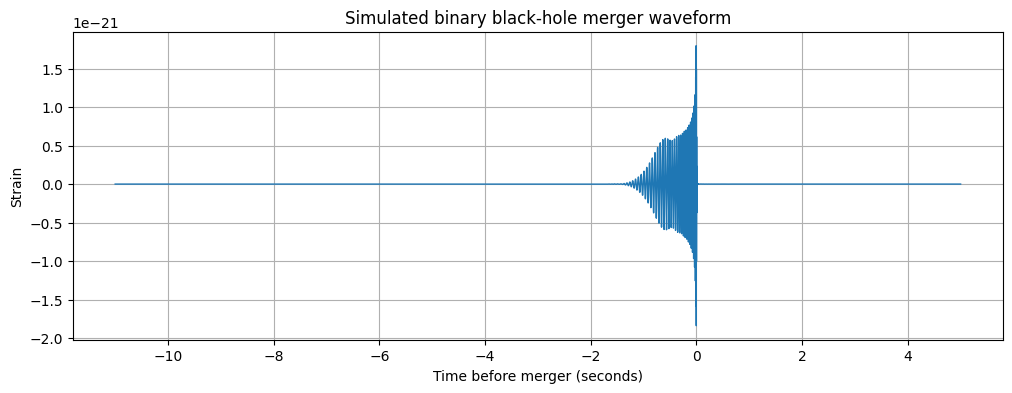

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(hp.sample_times, hp, linewidth=1)

plt.xlabel("Time before merger (seconds)")
plt.ylabel("Strain")
plt.title("Simulated binary black-hole merger waveform")
plt.grid(True)

plt.savefig("figures/01_clean_full_waveform.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Convert PyCBC TimeSeries to numpy
t = np.array(hp.sample_times)
y = np.array(hp)

# Select last 1 second before merger and small region after merger
mask = (t >= -1.0) & (t <= 0.05)

t_crop = t[mask]
clean = y[mask]

# Normalize clean waveform
clean = clean / np.max(np.abs(clean))

print("Cropped samples:", len(clean))
print("Clean waveform min:", clean.min())
print("Clean waveform max:", clean.max())

Cropped samples: 4301
Clean waveform min: -1.0
Clean waveform max: 0.9768590597063039


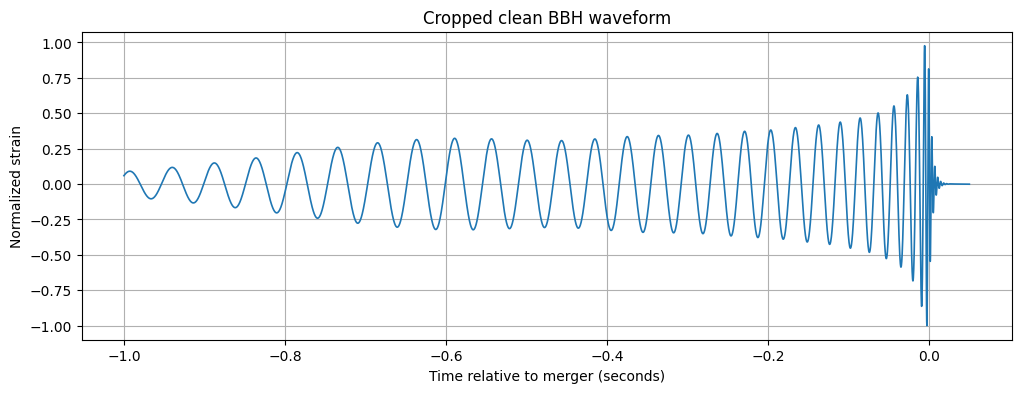

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(t_crop, clean, linewidth=1.2)

plt.xlabel("Time relative to merger (seconds)")
plt.ylabel("Normalized strain")
plt.title("Cropped clean BBH waveform")
plt.grid(True)

plt.savefig("figures/02_clean_cropped_waveform.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
np.random.seed(42)

noise_level = 0.35
noise = noise_level * np.random.normal(0, 1, size=len(clean))

noisy = clean + noise

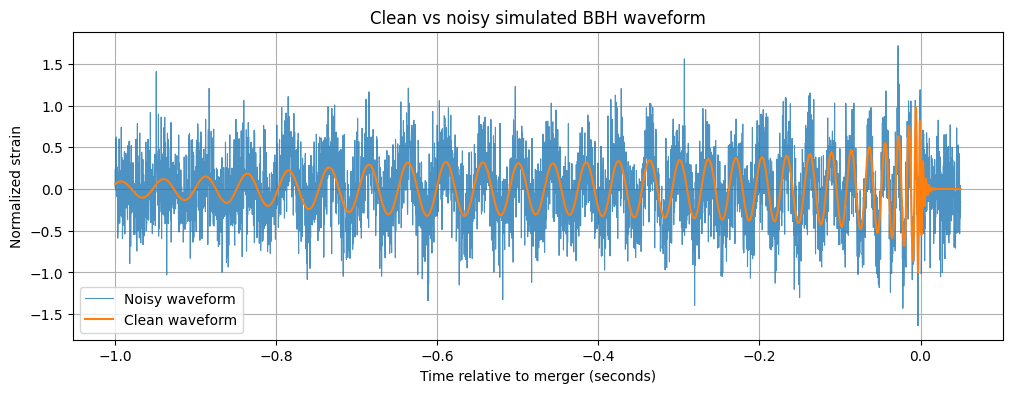

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(t_crop, noisy, label="Noisy waveform", linewidth=0.8, alpha=0.8)
plt.plot(t_crop, clean, label="Clean waveform", linewidth=1.5)

plt.xlabel("Time relative to merger (seconds)")
plt.ylabel("Normalized strain")
plt.title("Clean vs noisy simulated BBH waveform")
plt.legend()
plt.grid(True)

plt.savefig("figures/03_clean_vs_noisy_waveform.png", dpi=300, bbox_inches="tight")
plt.show()

#A simulated GW150914-like binary black-hole waveform was normalized and contaminated with Gaussian noise to create a controlled denoising problem. The clean waveform represents the target signal, while the noisy waveform serves as the input for classical and machine-learning denoising methods.

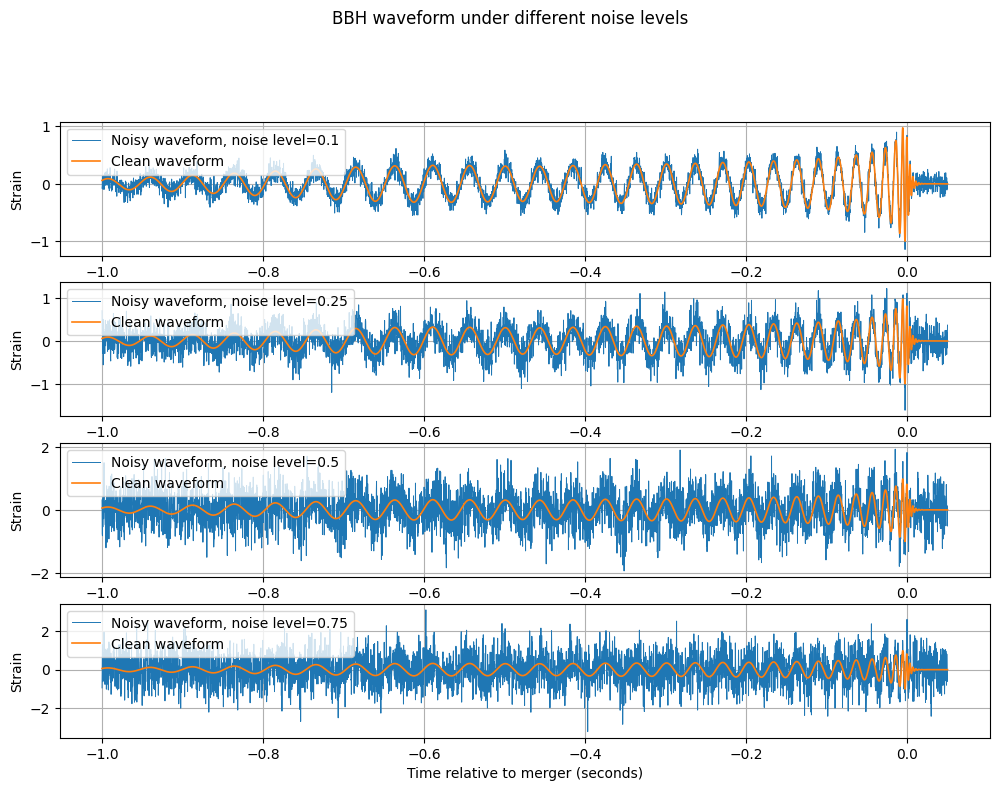

In [ ]:
noise_levels = [0.1, 0.25, 0.5, 0.75]

plt.figure(figsize=(12, 8))

for i, nl in enumerate(noise_levels, 1):
    noisy_signal = clean + nl * np.random.normal(0, 1, size=len(clean))

    plt.subplot(len(noise_levels), 1, i)
    plt.plot(t_crop, noisy_signal, linewidth=0.7, label=f"Noisy waveform, noise level={nl}")
    plt.plot(t_crop, clean, linewidth=1.2, label="Clean waveform")
    plt.ylabel("Strain")
    plt.grid(True)
    plt.legend(loc="upper left")

plt.xlabel("Time relative to merger (seconds)")
plt.suptitle("BBH waveform under different noise levels", y=1.02)

plt.savefig("figures/04_multiple_noise_levels.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:

np.save("data/t_crop.npy", t_crop)
np.save("data/clean_waveform.npy", clean)
np.save("data/noisy_waveform_noise_035.npy", noisy)

print("Saved clean and noisy waveform data.")


Saved clean and noisy waveform data.


In [ ]:
num_samples = 1000

X_noisy = []
Y_clean = []

for i in range(num_samples):
    nl = np.random.uniform(0.1, 0.8)
    noise = nl * np.random.normal(0, 1, size=len(clean))
    noisy_signal = clean + noise

    X_noisy.append(noisy_signal)
    Y_clean.append(clean)

X_noisy = np.array(X_noisy)
Y_clean = np.array(Y_clean)

# Add channel dimension for 1D CNN / autoencoder
X_noisy = X_noisy[..., np.newaxis]
Y_clean = Y_clean[..., np.newaxis]

print("X_noisy shape:", X_noisy.shape)
print("Y_clean shape:", Y_clean.shape)

np.save("data/X_noisy.npy", X_noisy)
np.save("data/Y_clean.npy", Y_clean)

X_noisy shape: (1000, 4301, 1)
Y_clean shape: (1000, 4301, 1)


In [ ]:
#A GW150914-like binary black-hole waveform was generated and normalized. Gaussian noise was added at multiple levels to create controlled noisy observations. The resulting plots show that the waveform becomes increasingly difficult to identify as the noise amplitude increases. These clean-noisy waveform pairs will be used for evaluating classical filtering and autoencoder-based denoising methods.

In [ ]:
np.save("data/t_crop.npy", t_crop)
np.save("data/clean_waveform.npy", clean)
np.save("data/noisy_waveform_noise_035.npy", noisy)

print("Saved clean and noisy waveform data.")

Saved clean and noisy waveform data.
